Loading Iris Dataset...

Dataset Shape: (150, 5)
Column Names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'species']

FIRST 5 ROWS
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm

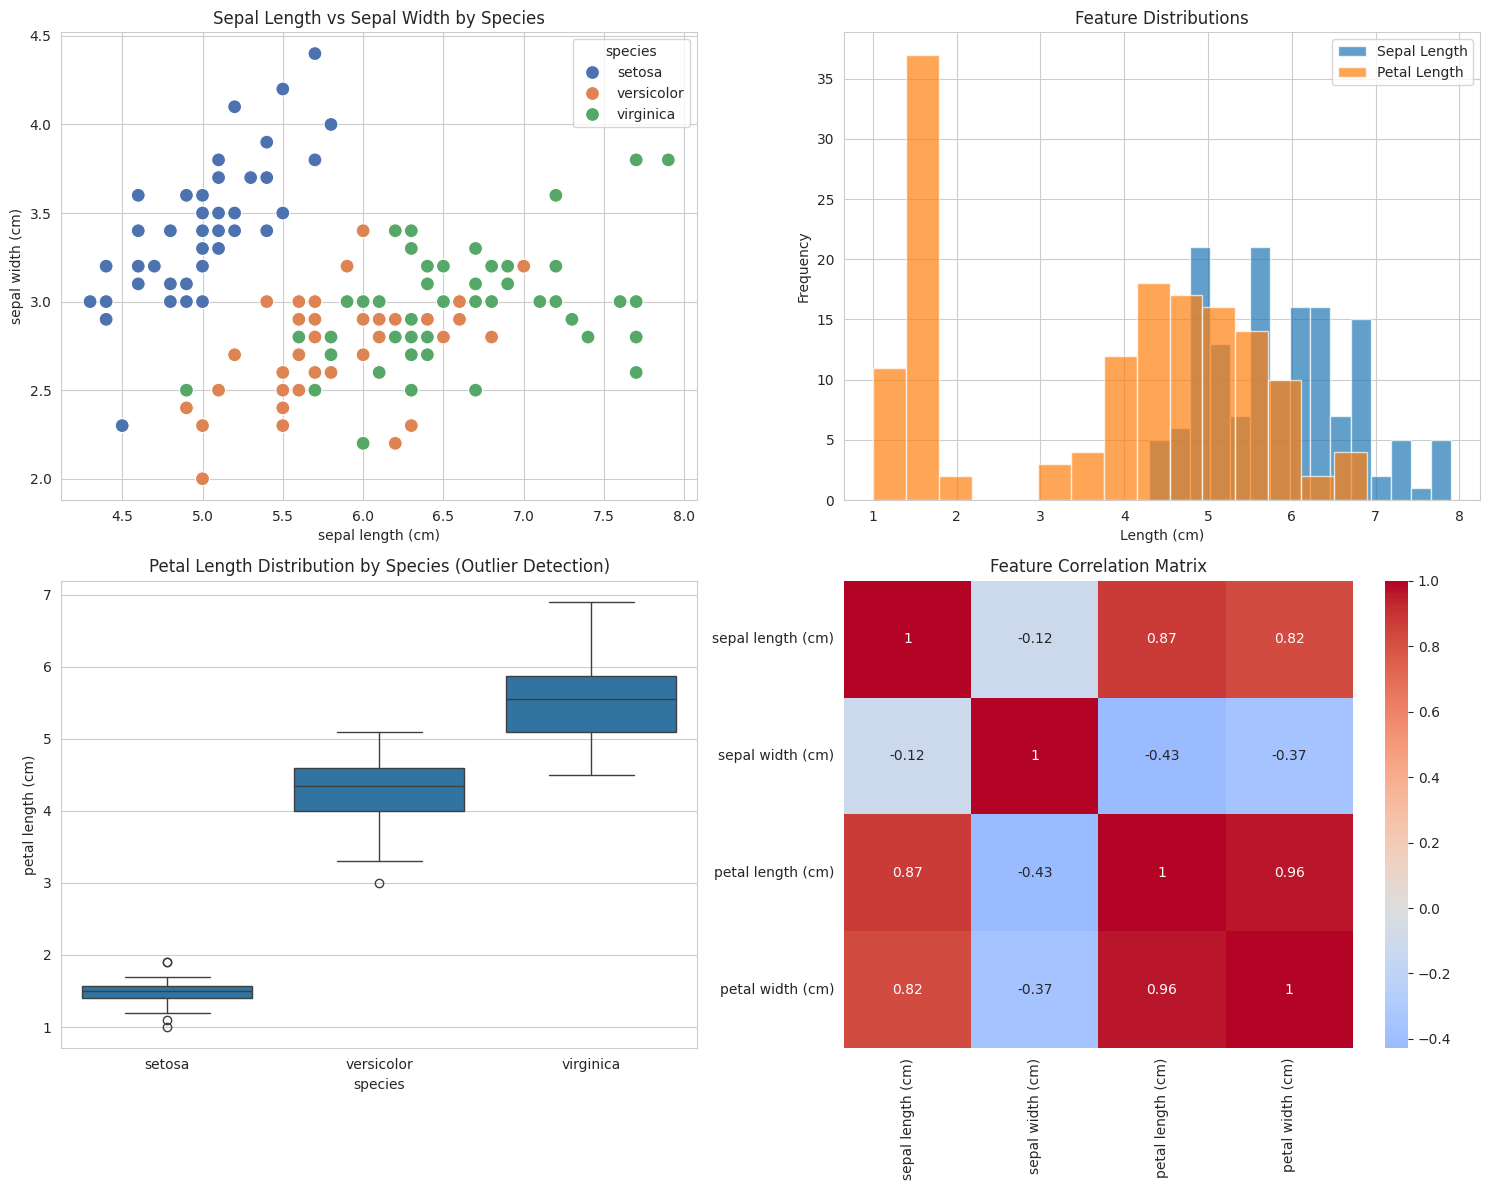

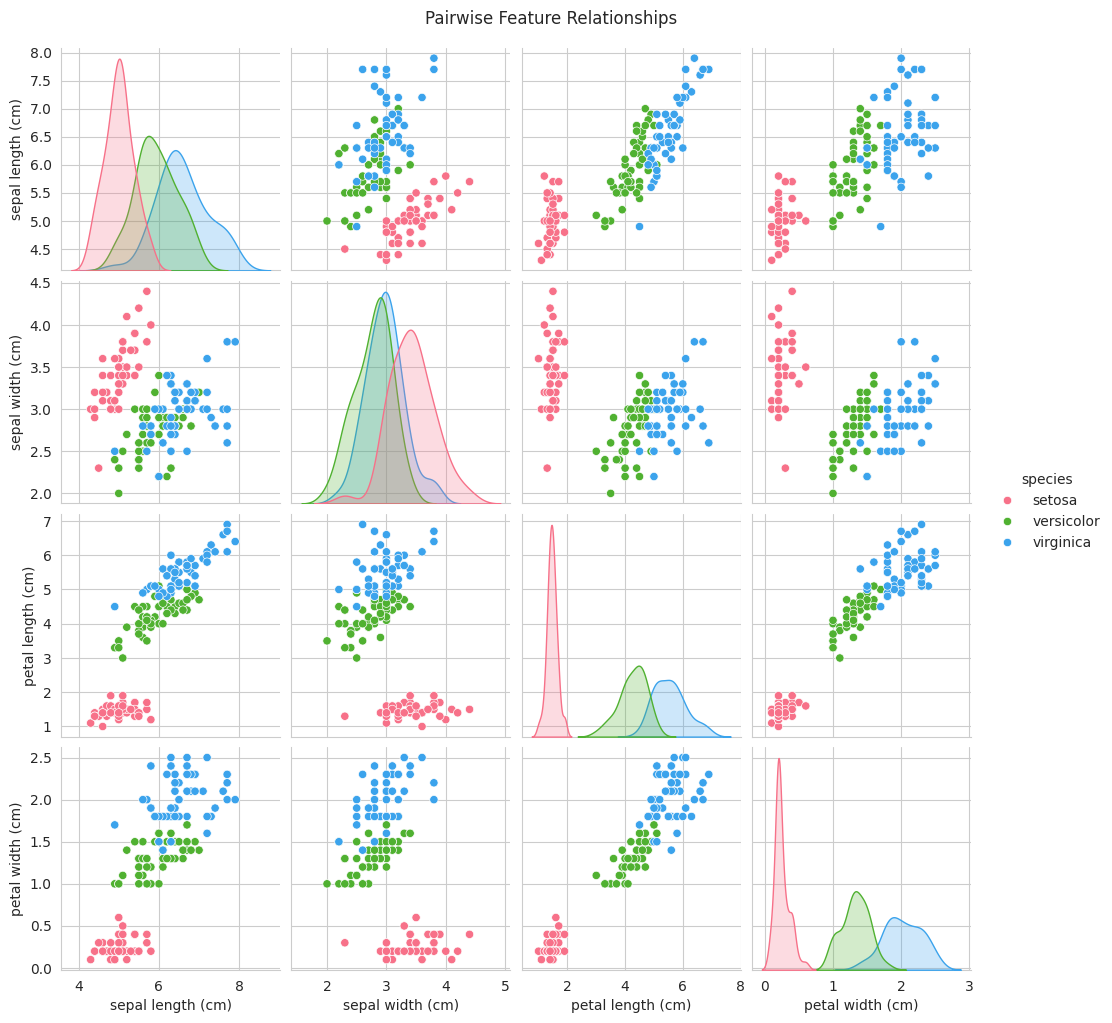


Key Insights:
- Dataset contains 150 samples with 4 features
- No missing values detected
- Petal length/width show strong correlation with species
- Setosa is linearly separable from other species


In [1]:
# task1_iris_eda.ipynb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris



# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# 1. Load Dataset
print("Loading Iris Dataset...")
# Method 1: From sklearn
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = [iris.target_names[i] for i in iris.target]

# Method 2: Alternatively via seaborn
# df = sns.load_dataset('iris')

print(f"\nDataset Shape: {df.shape}")
print(f"Column Names: {list(df.columns)}")

# 2. Initial Inspection
print("\n" + "="*50)
print("FIRST 5 ROWS")
print("="*50)
print(df.head())

print("\n" + "="*50)
print("DATASET INFO")
print("="*50)
df.info()

print("\n" + "="*50)
print("SUMMARY STATISTICS")
print("="*50)
print(df.describe())

# 3. Visualizations
fig = plt.figure(figsize=(15, 12))

# Scatter plot - Pairplot for relationships
plt.subplot(2, 2, 1)
sns.scatterplot(data=df, x='sepal length (cm)', y='sepal width (cm)',
                hue='species', palette='deep', s=100)
plt.title('Sepal Length vs Sepal Width by Species')

# Histograms - Distribution of features
plt.subplot(2, 2, 2)
df['sepal length (cm)'].hist(bins=15, alpha=0.7, label='Sepal Length')
df['petal length (cm)'].hist(bins=15, alpha=0.7, label='Petal Length')
plt.xlabel('Length (cm)')
plt.ylabel('Frequency')
plt.title('Feature Distributions')
plt.legend()

# Box plots - Outlier detection
plt.subplot(2, 2, 3)
sns.boxplot(data=df, x='species', y='petal length (cm)')
plt.title('Petal Length Distribution by Species (Outlier Detection)')

# Correlation heatmap
plt.subplot(2, 2, 4)
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')

plt.tight_layout()
plt.savefig('iris_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Additional: Pairplot for comprehensive relationships
pairplot = sns.pairplot(df, hue='species', palette='husl', height=2.5)
pairplot.fig.suptitle('Pairwise Feature Relationships', y=1.02)
plt.show()

print("\nKey Insights:")
print(f"- Dataset contains {df.shape[0]} samples with {df.shape[1]-1} features")
print(f"- No missing values detected")
print(f"- Petal length/width show strong correlation with species")
print(f"- Setosa is linearly separable from other species")